# Quantum Singular Value Transformation via Quantum Signal Processing

Quantum Singular Value Transformation (QSVT) is an algorithmic framework for applying bounded polynomial functions to the singular values of a matrix in the quantum setting. It unifies many quantum linear-algebraic algorithms as special cases or close analogues, including HHL-like matrix inversion, amplitude amplification, and Hamiltonian simulation.

We will begin by exploring quantum signal processing (QSP) and then see how it lifts to the QSVT paradigm. Succinctly, QSP implements a polynomial transformation of a single normalized signal parameter, typically in $[-1,1]$, through a quantum circuit. QSVT lifts the same idea to a block-encoded matrix: one applies a univariate polynomial to each singular value of the encoded operator, so the result behaves like replacing $\Sigma$ with $p(\Sigma)$ in an SVD $A=W\Sigma V^\dagger$, subject to the feasibility constraints such as boundedness, degree, and parity conventions. 


At a high level, this belongs to the broader mathematical idea of functional calculus: defining meaningful expressions such as $f(A)$ for an operator or matrix $A$. For Hermitian inputs, this is often phrased in terms of transforming eigenvalues. In QSVT, the object of study is more generally the singular values of a block-encoded matrix. QSVT was introduced by Gilyén, Su, Low, and Wiebe in [*Quantum singular value transformation and beyond: exponential improvements for quantum matrix arithmetics*](https://arxiv.org/abs/1806.01838).

---
### Table of contents 

1. QSP
2. QSP Implementation
3. QSVT
4. QSVT Implementation
5. QSVT as a Unifying Framework
6. Comparison with Classical SVT
7. Conclusion 

### Appendix

8. Appendix 1: Biography
9. Appendix 2: References and Suggested Readings


---
### QSP

Before we delve into the details of QSP, let us first state concise definitions of QSP and QSVT in one place. This helps fix the big picture before we gradually move from QSP to QSVT.

$$
\mathrm{QSP}: x \mapsto p(x), 
\qquad
\mathrm{QSVT}: A \mapsto p^{(\mathrm{SV})}(A)
$$
where $x$ is a scalar signal parameter, $A$ is an encoded operator, and $p^{(\mathrm{SV})}(A)$ denotes applying $p$ to the singular values of the encoded operator $A$.

We will answer "how does QSP evaluate a polynomial $p(x)$?" in steps. The modern formulation of quantum signal processing is widely attributed to Guang Hao Low and Isaac L. Chuang in [*Optimal Hamiltonian Simulation by Quantum Signal Processing*](https://arxiv.org/pdf/1606.02685).

First, in standard QSP with $d+1$ phases, the target polynomial $p(x)$ is usually taken to satisfy:

- $p$ is a real polynomial of degree at most $d$.
- $p(-x)=(-1)^d p(x)$, so all nonzero terms have the same parity (all even powers or all odd powers).
- Boundedness on the domain: $|p(x)|\leq 1$ for all $x\in[-1,1]$.

In practice, if a polynomial does not satisfy these conditions, it is preprocessed before applying QSP. For example, if its magnitude exceeds $1$ on $[-1,1]$, it can be rescaled; if it has mixed parity, it can be split into even and odd components, each handled by QSP separately and then recombined. Thus, these are practical conditions for applying standard QSP directly, while broader target functions can still be treated through scaling, decomposition, and polynomial approximation. For the remainder of the QSP derivation, we assume the target polynomial $p(x)$ satisfies the QSP admissibility conditions above. In later code demonstrations, we will also use target functions that do not satisfy these conditions directly, and handle them through preprocessing (e.g., scaling, parity splitting, or polynomial approximation) before applying QSP.

Let
$$
p(x)=a_d x^d+a_{d-1}x^{d-1}+\cdots+a_1 x+a_0=\sum_{k=0}^d a_k x^k.
$$

We take the signal operator from [PennyLane's tutorial on QSVT](https://pennylane.ai/qml/demos/tutorial_intro_qsvt):
$$
U(a)=\begin{bmatrix}
a & \sqrt{1-a^2}\\
\sqrt{1-a^2} & -a
\end{bmatrix}.
$$

Note that in the literature this operator may be defined under a different convention, but they are ultimately equivalent up to the appropriate basis change. For example, Martyn, Rossi, Tan, and Chuang in [*A Grand Unification of Quantum Algorithms*](https://arxiv.org/abs/2105.02859) define the signal rotation operator as:

$$
W(a) = \begin{bmatrix}
a & i\sqrt{1-a^2} \\
i\sqrt{1-a^2} & a
\end{bmatrix}
$$

Indeed, [`pyqsp`](https://github.com/ichuang/pyqsp) package in GitHub notes (as of April 2026):

> The theory of QSP is not only under active development, but comprises multiple subtly different conventions, each of which can use different terminology compared the barebones outline given here. These included conventions for how the signal is encoded, how the phases are applied, the basis to measure in, whether one desires to transform eigenvalues or singular values, whether the classical algorithm to find these phases is exact or iterative, and so on.

One can check that $U(a)$ is indeed a valid unitary operator. The signal operator $U(a)$ is combined with the signal-processing operator
$$
S(\phi)=\begin{bmatrix}
e^{i\phi} & 0\\
0 & e^{-i\phi}
\end{bmatrix},
$$
by alternating them for a fixed $a$ and a chosen list of phases $\phi_0,\ldots,\phi_d$. For suitable phases, the resulting product takes the form
$$
S(\phi_0)\prod_{k=1}^d U(a)\,S(\phi_k)
= \begin{bmatrix}
p(a) & g_{01}(a)\\
g_{10}(a) & g_{11}(a)
\end{bmatrix},
$$
where $p(a)$ is the evaluation of $p(x)$ at $x=a$! The entries $g_{01}(a), g_{10}(a), g_{11}(a)$ are determined by expanding the product, but they are not of interest. 

As a straightforward example, suppose $\phi_0=\pi$ and $\phi_1=0$. Then $S(\phi_0)=-I$ and $S(\phi_1)=I$, therefore
$$
S(\phi_0)\,U(a)\,S(\phi_1)=-U(a)=
\begin{bmatrix}
-a & -\sqrt{1-a^2}\\
-\sqrt{1-a^2} & a
\end{bmatrix}.
$$
In particular, the $(1,1)$ entry is $-a$. So these phases simply flip the sign of the top-left signal response; equivalently, if one is targeting the linear polynomial $p(a)=a$, this choice realizes $p(a)=-a$.

The promise of the QSP paradigm for a polynomial that satisfies the QSP admissibility constraints is that suitable phase lists exist and can be computed efficiently. See Theorems 1 and 2 of [*Optimal Hamiltonian Simulation by Quantum Signal Processing*](https://arxiv.org/abs/1606.02685). 

A more recent extension is generalized quantum signal processing (GQSP), introduced by [Motlagh and Wiebe](https://arxiv.org/abs/2308.01501). Standard QSP uses a fixed style of signal-processing rotation, whereas GQSP allows more general $\mathrm{SU}(2)$ rotations as the signal-processing operators. This gives more flexibility in the class of transformations one can realize and can make finding the required angles more direct in some settings. The tradeoff is that this extra flexibility comes with more parameters to choose than in ordinary QSP, so the resulting circuit may be less compact.


While we will not cover the classical techniques in depth, there are various methods for computing the angular phases. Many implementations use built-in routines for this, and the task is usually delegated to well-developed software packages.

---
### QSP Implementation

We will now implement QSP to reconstruct a polynomial. For demonstration, consider
$$
p(x)=x^5+4x^4+2x^3+2x^2+2.
$$
We define $p(x)$, split it into even and odd parts, and rescale each part so the magnitude is at most $1$ on $[-1,1]$. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

# target polynomial pieces
def p_full(x):
    return x**5 + 4 * x**4 + 2 * x**3 + 2 * x**2 + 2

def p_even(x):
    return 4 * x**4 + 2 * x**2 + 2

def p_odd(x):
    return x**5 + 2 * x**3

# scale so |P|<=1 on [-1,1] for each parity part
x_scale_grid  = np.linspace(-1, 1, 20001) 
scale_even = 0.99 / np.max(np.abs(p_even(x_scale_grid ))) # 0.99 (instead of 1.00) is a safety margin against floating-point roundoff.
scale_odd = 0.99 / np.max(np.abs(p_odd(x_scale_grid )))

# Polynomial coefficients are in ascending power order:
# [a0, a1, a2, ...] means a0 + a1*x + a2*x^2 + ...

# Even part: 2 + 2x^2 + 4x^4
poly_even = np.array([2.0, 0, 2, 0, 4]) * scale_even

# Odd part: 2x^3 + x^5
poly_odd = np.array([0.0, 0, 0, 2, 0, 1]) * scale_odd

As mentioned earlier, QSP works because there exists a set of phase angles that makes an alternating product of the signal operator $U(a)$ and signal-processing operator $S(\phi)$ realize the target polynomial response.

PennyLane provides a built-in routine, [`qml.poly_to_angles`](https://docs.pennylane.ai/en/stable/code/api/pennylane.poly_to_angles.html), which takes:

> - `poly` (`tensor_like`): coefficients of the polynomial ordered from lowest to highest power.
> - `routine` (`str`): the routine for which the angles are computed. Must be one of `"QSP"`, `"QSVT"`, or `"GQSP"`.
> - `angle_solver` (`str`): method used to compute the angles.
>   - `"root-finding"`: effective for polynomial degrees up to approximately $1000$.
>   - `"iterative"`: effective for polynomial degrees higher than approximately $1000$ for `"QSP"` and `"QSVT"`.

So in practice, we specify the polynomial coefficients and the desired routine, and PennyLane returns one valid phase list that implements the corresponding transform in that convention.

In [2]:
# Angles computed in PennyLane
angles_even = qml.poly_to_angles(poly=poly_even, routine="QSVT", angle_solver="root-finding")
angles_odd = qml.poly_to_angles(poly=poly_odd, routine="QSVT", angle_solver="root-finding")

print("angles_even =", np.array2string(np.asarray(angles_even), formatter={"float_kind": lambda x: f"{x:.2e}"}))
print("angles_odd  =", np.array2string(np.asarray(angles_odd), formatter={"float_kind": lambda x: f"{x:.2e}"}))

angles_even = [-3.93e+00 1.57e+00 8.32e-01 9.81e-01 6.85e-01]
angles_odd  = [-5.50e+00 1.57e+00 1.57e+00 6.59e-01 1.09e+00 7.47e-01]


Now, to apply QSP in PennyLane, it is useful to understand how these computations are organized in the API. PennyLane provides two related interfaces: lowercase [`qsvt()`](https://docs.pennylane.ai/en/stable/code/api/pennylane.qsvt.html), a high-level function, and uppercase [`QSVT()`](https://docs.pennylane.ai/en/stable/code/api/pennylane.QSVT.html), an operator class. The `qsvt` function is a wrapper that handles angle computation and block-encoding setup internally, then returns a `QSVT` operator. By contrast, when using `QSVT` directly, one provides the block-encoding operator and projector phase operators explicitly, with angles computed beforehand. In short, `qsvt` is higher-level and convenient, while `QSVT` offers finer control. In this tutorial, we use `QSVT` so the internal steps remain visible. 

As discussed, in the `QSVT` workflow we provide two inputs: a block-encoding operator and a list of projector phase operators. In the one-qubit QSP setting, these correspond to the signal operator and the signal-processing phases, respectively.

For phase operations, one may use [`PhaseShift`](https://docs.pennylane.ai/en/stable/code/api/pennylane.PhaseShift.html), which acts on a single qubit, or its broader projector-controlled variant [`PCPhase`](https://docs.pennylane.ai/en/stable/code/api/pennylane.PCPhase.html). In the one-qubit case, we set `dim=1`.

For the signal operator, we need a gate equivalent, up to global phase, to $U(a)$. A standard $x$-rotation in PennyLane is [`RX`](https://docs.pennylane.ai/en/stable/code/api/pennylane.RX.html):
$$
R_X(\theta)=e^{-i\theta X/2}=
\begin{bmatrix}
\cos(\theta/2) & -i\sin(\theta/2)\\
-i\sin(\theta/2) & \cos(\theta/2)
\end{bmatrix}.
$$

Set
$$
\theta=2\arccos(a).
$$
Then
$$
\cos(\theta/2)=a,\qquad
\sin(\theta/2)=\sqrt{1-a^2},
$$
so
$$
R_X(2\arccos(a))=
\begin{bmatrix}
a & -i\sqrt{1-a^2}\\
-i\sqrt{1-a^2} & a
\end{bmatrix}.
$$

This is a QSP signal operator, up to phase/basis convention. Therefore, using
```python
qml.RX(2*np.arccos(a), wires=0)
```
provides a valid one-qubit signal embedding for QSP constructions.

Additionally, since we are simulating a quantum circuit, we have access to primitives such as [`qml.matrix`](https://docs.pennylane.ai/en/stable/code/api/pennylane.matrix.html), which returns the matrix representation of a quantum circuit. Using `np.real`, one can then directly read off the top-left entry of the resulting unitary. On quantum hardware, this entry is not directly accessible; extracting it requires protocols such as the [Hadamard test](https://en.wikipedia.org/wiki/Hadamard_test) or tomography-based reconstruction through repeated sampling.

That said, in practice one is usually not interested in the numerical value of the matrix entry itself. The QSP/QSVT circuit is typically used as a subroutine within a larger protocol, where the polynomial transformation is applied coherently to a quantum state and the desired information is then extracted through measurement, for example estimating expectation values, ground state energies, or properties of the solution to a linear system. This is analogous to how HHL is used: the goal is usually statistical information about $A^{-1}|b\rangle$, not direct entry-by-entry readout.

Now that we have the necessary background, we implement polynomial reconstruction of $p(x)$ via QSP in PennyLane.

In [3]:
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def qsvt_state_from_x(x_value, phase_angles):
    # Numerical guard only: keep arccos input valid
    x_value = np.clip(x_value, -1.0, 1.0)
    
    # Scalar signal embedding U(x) via RX(2 arccos x)
    signal_block = qml.RX(2 * np.arccos(x_value), wires=0)
    
    # Convert phase list into projector-controlled phase gates
    projector_phases = [
        qml.PCPhase(float(phi), dim=1, wires=0) for phi in phase_angles
    ]
    
    # QSVT template (QSP is a special case here)
    qml.QSVT(signal_block, projector_phases)

    return qml.state()
    
def real_top_left_entry(x_value, phase_angles):
    state = qsvt_state_from_x(x_value, phase_angles)
    # For this 1-qubit construction, U_{00} is the |0> amplitude
    return np.real(state[0])

def reconstructed_polynomial_value(x_value):
    even_part = real_top_left_entry(x_value, angles_even) / scale_even
    odd_part = real_top_left_entry(x_value, angles_odd) / scale_odd
    return even_part + odd_part

We then plot the original function and its QSP reconstruction on the left, and the absolute error on the right.

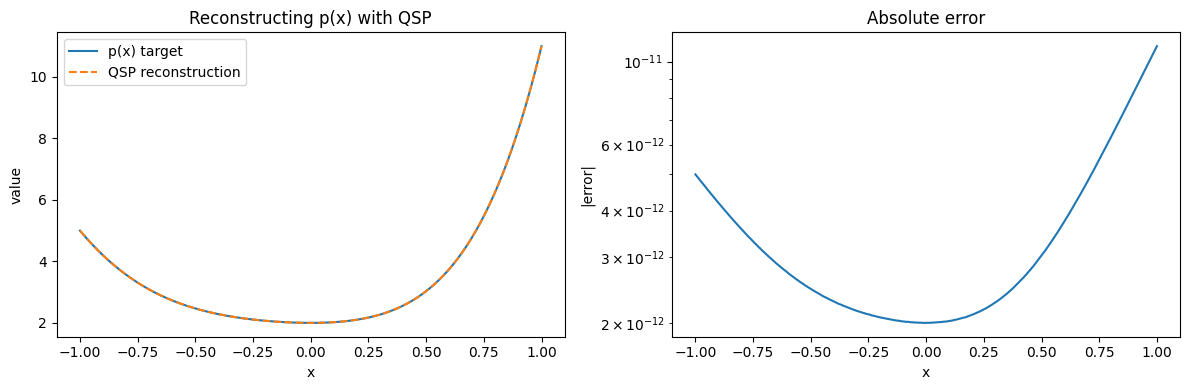

In [4]:
# --- evaluate on plotting grid ---
x_plot_grid = np.linspace(-1, 1, 400)
target_vals = p_full(x_plot_grid)
recon_vals = np.array([reconstructed_polynomial_value(x) for x in x_plot_grid])
err = np.abs(recon_vals - target_vals)

# --- side-by-side plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: target vs reconstruction
axes[0].plot(x_plot_grid, target_vals, label="p(x) target")
axes[0].plot(x_plot_grid, recon_vals, "--", label="QSP reconstruction")
axes[0].set_xlabel("x")
axes[0].set_ylabel("value")
axes[0].set_title("Reconstructing p(x) with QSP")
axes[0].legend()

# Right: absolute error
axes[1].semilogy(x_plot_grid, err + 1e-16)
axes[1].set_xlabel("x")
axes[1].set_ylabel("|error|")
axes[1].set_title("Absolute error")

plt.tight_layout()
plt.show()

The visualizations show that QSP reconstructs $p(x)$ almost exactly, as confirmed by the absolute error, whose magnitude is on the order of $10^{-12}$.

We can also draw the circuit in PennyLane. To do this, we pick a point in the range $[-1,1]$; here we use $x=0.3$, but any valid value would work. We also choose which parity channel to display (even or odd).

By default, PennyLane shows the construction as a single `QSVT` template block in circuit visualization. To inspect the internal gate sequence, we decompose the `QSVT` operator first and then visualize the result. This is why the second visualization gives a more detailed view of the QSVT/QSP construction.

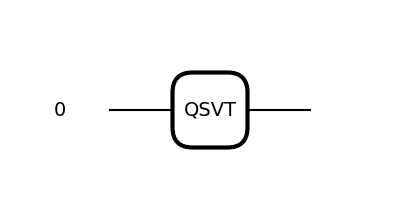

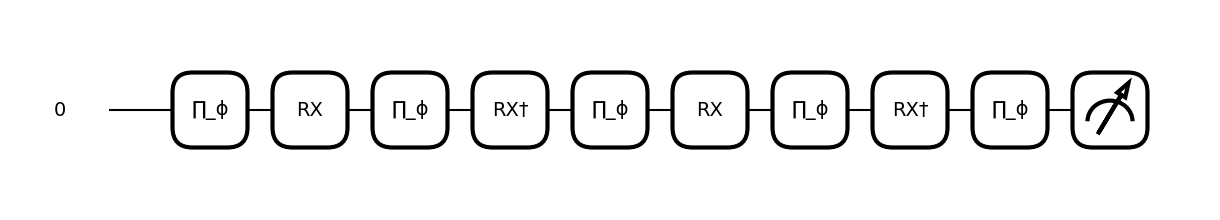

In [5]:
x0 = 0.3
phase_angles = angles_even  # or angles_odd

# Build one QSVT operator instance
signal_block = qml.RX(2 * np.arccos(np.clip(x0, -1, 1)), wires=0)
projector_phases = [qml.PCPhase(float(phi), dim=1, wires=0) for phi in phase_angles]
op = qml.QSVT(signal_block, projector_phases)

# 1) Compact view (template-level)
fig1, ax1 = qml.draw_mpl(lambda: qml.apply(op))()
plt.show()

# 2) Expanded/decomposed view
decomp_ops = qml.QSVT(signal_block, projector_phases).decomposition()
@qml.qnode(dev)
def qsvt_expanded():
    for g in decomp_ops:
        qml.apply(g)
    return qml.state()
qml.draw_mpl(qsvt_expanded, level="device")()
plt.show()

We quickly visualize a few other function instances, not necessarily polynomials, which can be approximated by polynomials using methods such as Chebyshev approximation, and reconstruct them using QSP.

In [6]:
# helper: split coefficients into even/odd parts (ascending powers)
def split_even_odd_coeffs(coef):
    coef = np.asarray(coef, dtype=float)
    even = coef.copy(); even[1::2] = 0.0
    odd  = coef.copy(); odd[0::2]  = 0.0
    return even, odd

# helper: evaluate polynomial from ascending-power coeffs
def poly_eval_asc(coef, x):
    return sum(c * x**k for k, c in enumerate(coef))

def poly_to_qsvt_angles_safe(coef_scaled, angle_solver="root-finding"):
    c = np.trim_zeros(np.asarray(coef_scaled, dtype=float), trim="b")
    if c.size == 0 or np.allclose(c, 0.0):
        return None
    if c.size == 1:
        return None
    try:
        return qml.poly_to_angles(c, routine="QSVT", angle_solver=angle_solver)
    except (ValueError, AssertionError):
        return qml.poly_to_angles(c, routine="QSVT", angle_solver="iterative")

# helper: QSVT scalar evaluation of Re(U00) for one 
def make_u00_evaluator(angles):
    if angles is None:
        return lambda x: 0.0

    projs = [qml.PCPhase(float(phi), dim=1, wires=0) for phi in angles]

    @qml.qnode(dev)
    def circ(x):
        x = float(np.clip(x, -1.0, 1.0))
        block = qml.RX(2 * np.arccos(x), wires=0)
        qml.QSVT(block, projs)
        return qml.state()

    return lambda x: float(np.real(circ(x)[0]))

# fit target function with Chebyshev polynomial and reconstruct via QSP/QSVT
def reconstruct_function(func, degree=25, safety=0.99, n_fit=2000, n_plot=400):
    # fit polynomial in monomial basis on [-1,1] (via Chebyshev fit -> power basis)
    x_fit = np.linspace(-1, 1, n_fit)
    y_fit = func(x_fit)
    cheb = np.polynomial.Chebyshev.fit(x_fit, y_fit, deg=degree, domain=[-1, 1])
    power_poly = cheb.convert(kind=np.polynomial.Polynomial)   # ascending powers
    coef = power_poly.coef

    # parity split
    coef_even, coef_odd = split_even_odd_coeffs(coef)

    # scale each parity part to satisfy |P(x)| <= 1
    x_scale = np.linspace(-1, 1, 20001)
    max_even = np.max(np.abs(poly_eval_asc(coef_even, x_scale)))
    max_odd  = np.max(np.abs(poly_eval_asc(coef_odd,  x_scale)))

    scale_even = 1.0 if max_even == 0 else safety / max_even
    scale_odd  = 1.0 if max_odd  == 0 else safety / max_odd

    coef_even_s = coef_even * scale_even
    coef_odd_s  = coef_odd  * scale_odd

    angles_even = poly_to_qsvt_angles_safe(coef_even_s)
    angles_odd  = poly_to_qsvt_angles_safe(coef_odd_s)

    eval_even = make_u00_evaluator(angles_even)
    eval_odd  = make_u00_evaluator(angles_odd)

    # reconstruct on plotting grid
    x_plot = np.linspace(-1, 1, n_plot)
    target = func(x_plot)

    recon = np.empty_like(x_plot)
    for i, x in enumerate(x_plot):
        even_part = (eval_even(x) / scale_even) if max_even != 0 else 0.0
        odd_part  = (eval_odd(x)  / scale_odd)  if max_odd  != 0 else 0.0
        recon[i] = even_part + odd_part

    err = np.abs(recon - target)
    return x_plot, target, recon, err

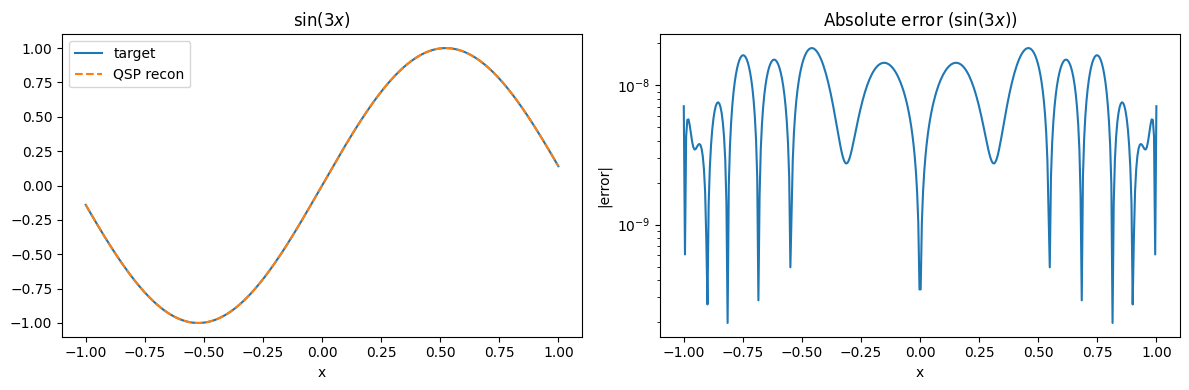

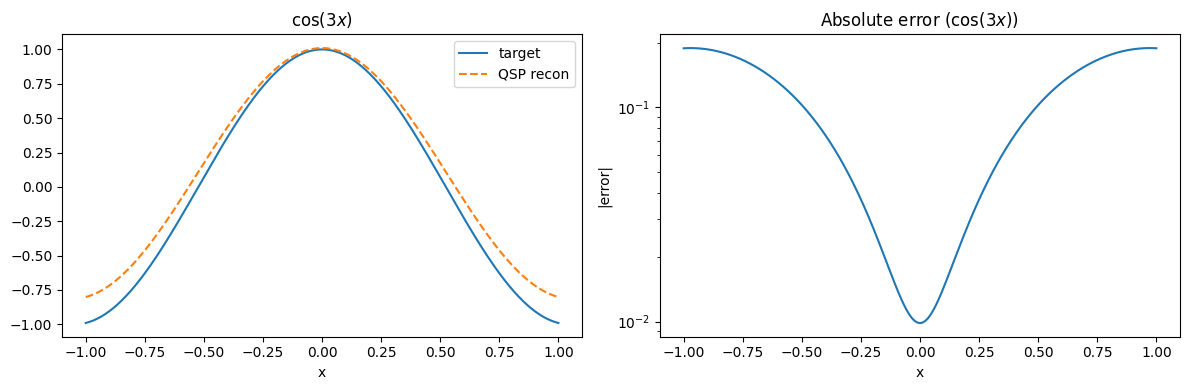

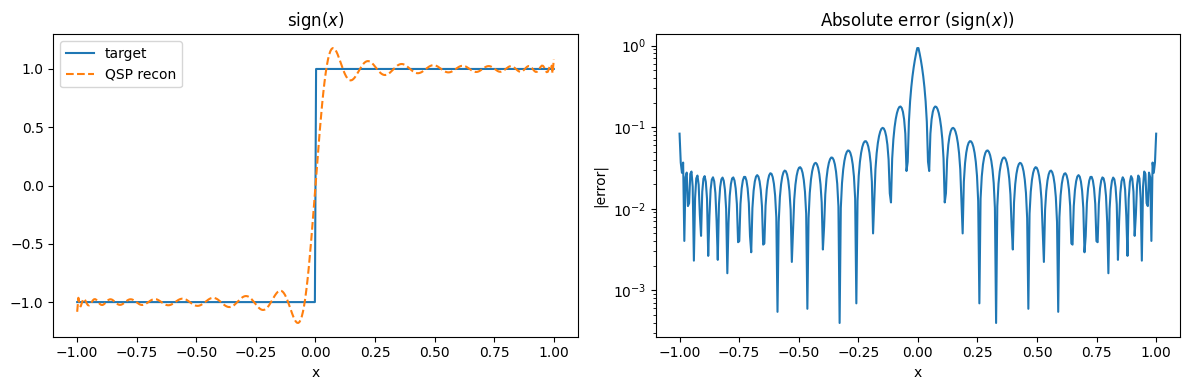

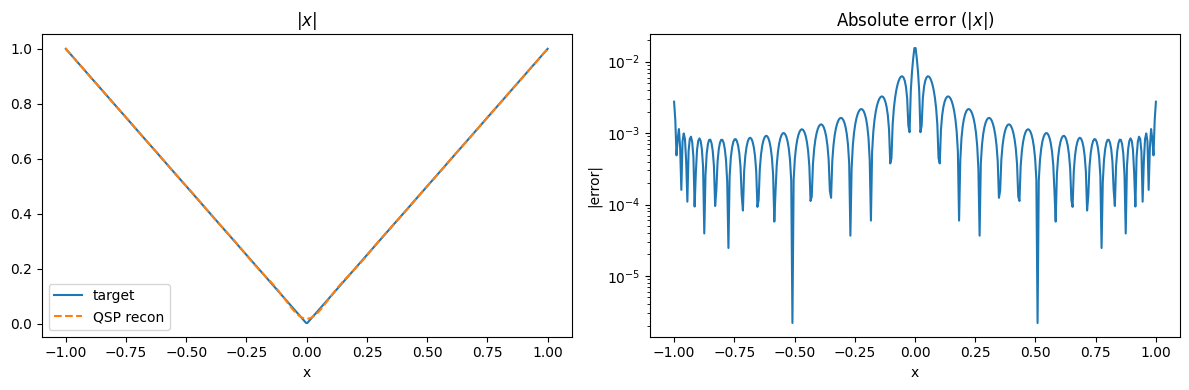

In [7]:
# ---- choose 4 targets ----
functions = {
    r"$\sin(3x)$": lambda x: np.sin(3*x),
    r"$\cos(3x)$": lambda x: np.cos(3*x),
    r"$\mathrm{sign}(x)$": lambda x: np.sign(x),
    r"$|x|$": lambda x: np.abs(x),
}

# Per-target Chebyshev degree for the fit.
degree_map = {
    r"$\sin(3x)$": 21,
    r"$\cos(3x)$": 21,
    r"$\mathrm{sign}(x)$": 41,
    r"$|x|$": 35,
}

for name, f in functions.items():
    x, y, yhat, err = reconstruct_function(f, degree=degree_map[name])

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(x, y, label="target")
    ax[0].plot(x, yhat, "--", label="QSP recon")
    ax[0].set_title(name)
    ax[0].set_xlabel("x")
    ax[0].legend()

    ax[1].semilogy(x, err + 1e-16)
    ax[1].set_title(f"Absolute error ({name})")
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("|error|")

    plt.tight_layout()
    plt.show()

We include a template for the QSP circuit.

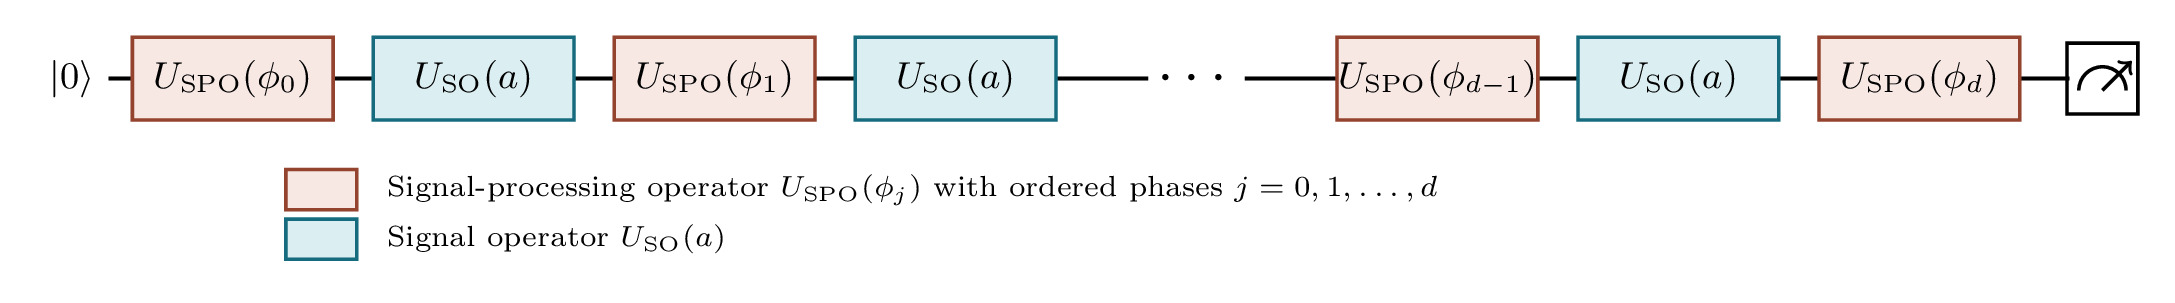

<p align="center"><em>
Figure: Generic QSP circuit template with alternating signal-processing gates $U_{\mathrm{SPO}}(\phi_j)$ and signal gates $U_{\mathrm{SO}}(a)$, followed by measurement. 
</em></p>

---
### QSVT 

Now that we have seen how QSP works, we can lift the same idea from a scalar signal parameter to a matrix-valued signal. In QSP, the signal is a scalar $a\in[-1,1]$. By alternating signal operators that depend on $a$ with signal-processing phase operators that depend on a chosen phase list, the resulting product unitary has a top-left entry that realizes the desired polynomial value $p(a)$. In QSVT, the scalar $a$ is replaced by a matrix $A$, and the goal is to apply a polynomial transformation to the singular values of $A$.

Let the singular value decomposition of $A$ be

$$
A = W \Sigma V^\dagger,
$$

where

$$
\Sigma = \operatorname{diag}(\sigma_1,\sigma_2,\dots,\sigma_r),
\qquad
\sigma_1\geq \sigma_2\geq \cdots \geq \sigma_r \geq 0.
$$

QSVT implements transformations of the form

$$
A = W\Sigma V^\dagger
\quad\longmapsto\quad
W p(\Sigma) V^\dagger,
$$

where

$$
p(\Sigma)=\operatorname{diag}(p(\sigma_1),p(\sigma_2),\dots,p(\sigma_r)).
$$

This is why the framework is called quantum singular value transformation: QSVT transforms the singular values of the encoded matrix while keeping the singular-vector basis fixed.

QSVT does not require $A$ to be square. In general, $A$ may be a rectangular matrix $A\in\mathbb{C}^{m\times n}$. For the purposes of this tutorial, however, we will focus on the square case where $A$ acts on $n$ qubits, so

$$
A\in\mathbb{C}^{2^n\times 2^n}.
$$

The matrix $A$ is encoded as a block of a larger unitary $U_A$, called a block-encoding of $A$. This encoding is not unique: different constructions may use different numbers of auxiliary qubits, different normalization factors, different data-access assumptions, and different circuits for realizing the larger unitary. These choices affect the cost of the QSVT procedure, but the abstract requirement is that some block of $U_A$ contains a normalized version of $A$.

If $h$ auxiliary qubits are used, then $U_A$ acts on $n+h$ qubits and has size

$$
2^{n+h}\times 2^{n+h}.
$$

The encoded block itself has size $2^n\times 2^n$, and is selected by projecting the auxiliary register onto $|0^h\rangle$:

$$
(\langle 0^h|\otimes I)U_A(|0^h\rangle\otimes I)=A/\alpha,
$$

where $\alpha\geq \|A\|$ is a normalization factor, with $\|A\|$ denoting the largest singular value of $A$. The value of $\alpha$ also depends on the encoding. Equivalently, one can think of $U_A$ as having the block structure

$$
U_A = \begin{bmatrix} A/\alpha & * \\ * & * \end{bmatrix}.
$$


The choice of block-encoding is itself a nontrivial part of the QSVT workflow. For example, one may construct $U_A$ using linear combinations of unitaries, state-preparation oracles, sparse-access oracles, or matrix-access oracles. [PennyLane's block-encoding tutorial](https://pennylane.ai/qml/demos/tutorial_block_encoding) provides a good starting point on this topic. The choice of block-encoding is separate from the choice of polynomial approximation method, such as Chebyshev or Taylor approximation, which determines the polynomial $p$ applied after the block-encoding is applied.




Thus, QSVT generalizes QSP by replacing the scalar signal $a$ with a block-encoded matrix $A/\alpha$. In this sense, QSP can be viewed as the special case of QSVT where the encoded matrix is $1\times 1$, namely a scalar $a\in[-1,1]$. 

The main requirement for the input matrix $A$ is that a normalized version $A/\alpha$ be available as a block of an efficiently implementable unitary. Thus the constraint on $A$ is primarily an encoding/access constraint: one must choose $\alpha\geq \|A\|$ so that the singular values of $A/\alpha$ lie in $[0,1]$, and one must have an efficient circuit or oracle construction for the corresponding block-encoding. The polynomial $p$ should still satisfy the QSVT admissibility conditions, such as boundedness, degree, and parity constraints.

---
### QSVT Implementation

For the purposes of demonstration, we let $A$ be a Hermitian matrix with positive eigenvalues in the range $[0,1]$. This choice simplifies the calculations because eigenvalues and singular values do not coincide in general. However, for positive semidefinite Hermitian matrices, the singular values are equal to the eigenvalues.

The analogous idea of quantum eigenvalue transformation is interesting and related, but distinct from QSVT. It is explored, for example, in [*Quantum eigenvalue processing*](https://arxiv.org/abs/2401.06240) by Guang Hao Low and Yuan Su. There, the authors note that
>  As eigenvalues are different from singular values for non-normal operators, these problems are out of reach of the existing quantum singular value algorithm and its descendants.

Now let

$$
A =
\begin{bmatrix}
0.7 & 0.2 \\
0.2 & 0.3
\end{bmatrix}.
$$

We first verify that $A$ is Hermitian and that its eigenvalues lie in $[0,1]$.

In [8]:
A = np.array([
    [0.7, 0.2],
    [0.2, 0.3]
], dtype=complex)

is_hermitian = np.allclose(A, A.conj().T)

eigenvalues = np.linalg.eigvalsh(A)
eigenvalues_in_unit_interval = np.all((eigenvalues >= 0) & (eigenvalues <= 1))

print("A =")
print(A)

print("\nIs A Hermitian?")
print(is_hermitian)

print("\nEigenvalues of A:")
print(eigenvalues)

print("\nAre all eigenvalues in [0, 1]?")
print(eigenvalues_in_unit_interval)

A =
[[0.7+0.j 0.2+0.j]
 [0.2+0.j 0.3+0.j]]

Is A Hermitian?
True

Eigenvalues of A:
[0.21715729 0.78284271]

Are all eigenvalues in [0, 1]?
True


Next, we need to encode the matrix $A$ as a block of a larger unitary. For the purposes of demonstration, we choose a particularly explicit encoding method that is similar in spirit to the signal operator used in QSP:

$$
U(A)=
\begin{bmatrix}
A & \sqrt{I-AA^\dagger}\\
\sqrt{I-A^\dagger A} & -A^\dagger
\end{bmatrix}.
$$

This construction is a standard unitary dilation of the contraction $A$, meaning it is valid when $\|A\|\leq 1$. In this dilation, $A$ appears directly as the top-left block of the larger unitary $U(A)$. More background can be found in the corresponding [dilation](https://en.wikipedia.org/wiki/Dilation_(operator_theory)) entry. The word "dilation" refers to enlarging the Hilbert space so that the original operator appears as a compressed block of a larger unitary. The word "contraction" refers to the condition $\|A\|\leq 1$, meaning that $A$ does not increase vector norms.

In PennyLane, this construction is available through [`qml.BlockEncode`](https://docs.pennylane.ai/en/stable/code/api/pennylane.BlockEncode.html#pennylane.BlockEncode).


The QSVT analogue of the QSP signal-processing operator is a projector-controlled phase operator. If $\Pi$ projects onto the block-encoded subspace, then we define

$$
\Pi_\phi =
e^{i\phi}\Pi + e^{-i\phi}(I-\Pi).
$$

Thus $\Pi_\phi$ applies the phase $e^{i\phi}$ on the encoded subspace and $e^{-i\phi}$ on its orthogonal complement. For a block-encoding where the first block contains $A$, this has the schematic form

$$
\Pi_\phi =
\begin{bmatrix}
e^{i\phi}I & 0\\
0 & e^{-i\phi}I
\end{bmatrix}.
$$

For our $2\times 2$ example, the block-encoding unitary is $4\times 4$, so the corresponding projector-controlled phase operator is

$$
\Pi_\phi =
\operatorname{diag}
(e^{i\phi},e^{i\phi},e^{-i\phi},e^{-i\phi}).
$$

The phase angles are still computed classically. As in QSP, we first choose a polynomial $p$ satisfying the admissibility conditions, and then use a phase-synthesis routine to find angles $\phi_0,\phi_1,\dots,\phi_d$ such that the resulting QSVT sequence implements the desired singular-value transformation. In PennyLane, the corresponding phase operators are implemented with `qml.PCPhase`.

Depending on the parity of the polynomial $p$, that is, whether $p$ is even or odd, the QSVT sequence takes slightly different forms. Parity in QSVT refers to the parity of the scalar polynomial $p(x)$.

For an even degree-$d$ polynomial, the QSVT sequence has the form

$$
\left[
\prod_{k=1}^{d/2}
\Pi_{\phi_{2k-1}} U(A)^\dagger \widetilde{\Pi}_{\phi_{2k}} U(A)
\right]
\Pi_{\phi_{d+1}}
=
\begin{pmatrix}
p^{(\mathrm{SV})}(A) & * \\
* & *
\end{pmatrix}.
$$

For an odd degree-$d$ polynomial, the QSVT sequence has the form

$$
\widetilde{\Pi}_{\phi_1} U(A)
\left[
\prod_{k=1}^{(d-1)/2}
\Pi_{\phi_{2k}} U(A)^\dagger \widetilde{\Pi}_{\phi_{2k+1}} U(A)
\right]
\Pi_{\phi_{d+1}}
=
\begin{pmatrix}
p^{(\mathrm{SV})}(A) & * \\
* & *
\end{pmatrix}.
$$

Here $U(A)$ is the block-encoding unitary. The operators $\Pi_\phi$ and $\widetilde{\Pi}_\phi$ are projector-controlled phase operators defined by

$$
\Pi_\phi=e^{i\phi}\Pi+e^{-i\phi}(I-\Pi),
\qquad
\widetilde{\Pi}_\phi=e^{i\phi}\widetilde{\Pi}+e^{-i\phi}(I-\widetilde{\Pi}).
$$

The projector $\Pi$ selects the subspace representing the input/domain of $A$, while $\widetilde{\Pi}$ selects the subspace representing the output/codomain of $A$. For the standard top-left block-encoding of a square matrix, these projectors are the same:

$$
\Pi=\widetilde{\Pi}=|0^h\rangle\langle 0^h|\otimes I.
$$

For rectangular matrices or more general projected-unitary encodings, they may differ.

The notation $p^{(\mathrm{SV})}(A)$ emphasizes that QSVT applies the polynomial $p$ to the singular values of $A$.


For demonstration, we aim to apply the function $\frac{1}{x}$ to the singular values of $A$. In this example, because $A$ is positive semidefinite and Hermitian, its singular values are equal to its eigenvalues.

First, note that $\frac{1}{x}$ is not a polynomial, so we approximate it by a polynomial using a Chebyshev-based method. Moreover, QSVT requires the implemented polynomial to be bounded, typically satisfying $|p(x)|\leq 1$ on $[-1,1]$. The function $\frac{1}{x}$ is not bounded near $x=0$ and also takes values larger than $1$ on much of $[-1,1]$, so we instead approximate a scaled inverse

$$
p(x)\approx \frac{c}{x},
$$

where $c$ is chosen so that $|p(x)|\leq 1$ on the interval of interest.

For numerical stability, we use the fact that the singular values of $A$ are bounded away from zero. If $\sigma_{\min}$ denotes the smallest singular value of $A$, we approximate $\frac{c}{x}$ only on

$$
[-1,-\sigma_{\min}]\cup[\sigma_{\min},1].
$$

The QSVT output then approximates

$$
p^{(\mathrm{SV})}(A)\approx cA^{-1}.
$$

Therefore, after extracting the transformed block, we divide by $c$ to compare against the original inverse $A^{-1}$.


In [9]:
A = np.array([
    [0.7, 0.2],
    [0.2, 0.3]
], dtype=float)

eigvals = np.linalg.eigvalsh(A)
sigma_min = eigvals[0]

print("Eigenvalues / singular values:", eigvals)
print("sigma_min:", sigma_min)

degree = 15

# Choose c below sigma_min so c/x is bounded by 1 on the spectrum interval.
c = 0.9 * sigma_min

# Approximate c/x away from zero on both positive and negative intervals.
x_pos = np.linspace(sigma_min, 1.0, 600)
x = np.concatenate([-x_pos[::-1], x_pos])
y = c / x

# Fit c/x using Chebyshev approximation, then convert to power-basis coefficients.
cheb_fit = np.polynomial.Chebyshev.fit(x, y, deg=degree, domain=[-1, 1])
poly = cheb_fit.convert(kind=np.polynomial.Polynomial).coef

# Keep only the odd part, since 1/x is odd.
poly[::2] = 0.0
poly[np.abs(poly) < 1e-12] = 0.0

grid = np.linspace(-1, 1, 5000)
max_abs = np.max(np.abs(np.polynomial.Polynomial(poly)(grid)))

print("Polynomial coefficients:")
print(poly)
print("max |p(x)| on [-1,1]:", max_abs)
print("c:", c)

Eigenvalues / singular values: [0.21715729 0.78284271]
sigma_min: 0.21715728752538094
Polynomial coefficients:
[    0.             6.81233994     0.           -85.65931812
     0.           523.89050396     0.         -1757.90826517
     0.          3397.58488699     0.         -3765.51463039
     0.          2220.54827199     0.          -539.59164724]
max |p(x)| on [-1,1]: 0.8240029146899595
c: 0.19544155877284286


In [10]:
# Compute QSVT phase angles for the polynomial
angles = qml.poly_to_angles(poly, "QSVT", angle_solver="iterative")

wires = [0, 1]

# block-encoding of A
block_encode = qml.BlockEncode(A, wires=wires)

# Projector-controlled phase operators
projectors = [
    qml.PCPhase(angles[i], dim=A.shape[0], wires=wires)
    for i in range(len(angles))
]

# Build the QSVT operator
qsvt_op = qml.QSVT(block_encode, projectors)

# Extract the full matrix of the QSVT operator
U_qsvt = qml.matrix(qsvt_op, wire_order=wires)

# Since A is 2x2, the transformed block is the top-left 2x2 block
qsvt_block = U_qsvt[:2, :2]

Since $A$ is Hermitian positive definite, we can write

$$
A = V\Sigma V^\dagger.
$$

In this case, the singular values of $A$ coincide with its positive eigenvalues. Therefore,

$$
A^{-1}=V\Sigma^{-1}V^\dagger.
$$

Thus, by using QSVT to approximate the map

$$
\sigma \mapsto \frac{1}{\sigma}
$$

on the singular values of $A$, we obtain an approximation to $A^{-1}$. In our implementation we actually approximate a scaled inverse,

$$
p(\sigma)\approx \frac{c}{\sigma},
$$

so the transformed block approximates

$$
p^{(\mathrm{SV})}(A)\approx cA^{-1}.
$$

After extracting the transformed block, we divide by $c$ to compare against the original inverse $A^{-1}$. This illustrates one powerful use of QSVT: matrix inversion can be implemented as a polynomial transformation of singular values.

We verify the numerical approximation and absolute error next.


In [11]:
# QSVT approximates c A^{-1}, so divide by c to recover A^{-1}
qsvt_inverse_estimate = qsvt_block / c
exact_inverse = np.linalg.inv(A)

print("QSVT estimate of A^{-1}:")
print(np.round(qsvt_inverse_estimate.real, 6))

print("\nExact A^{-1}:")
print(np.round(exact_inverse, 6))

print("\nAbsolute error:")
print(np.round(np.abs(qsvt_inverse_estimate.real - exact_inverse), 6))

QSVT estimate of A^{-1}:
[[ 1.717649 -1.023396]
 [-1.023396  3.76444 ]]

Exact A^{-1}:
[[ 1.764706 -1.176471]
 [-1.176471  4.117647]]

Absolute error:
[[0.047057 0.153075]
 [0.153075 0.353207]]


We see that the QSVT estimate of $A^{-1}$ is a good approximation of the exact inverse. We used a degree-15 polynomial for this approximation. A more precise approximation can be obtained by increasing the polynomial degree, at the cost of a deeper QSVT circuit.

We can now plot heatmaps of $A^{-1}$, its QSVT approximation, and the absolute error to inspect the result visually.

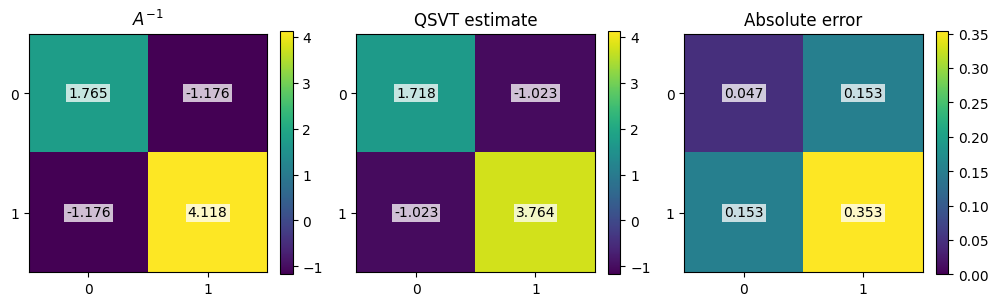

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

estimate = qsvt_inverse_estimate.real
error = np.abs(estimate - exact_inverse)

value_min = min(exact_inverse.min(), estimate.min())
value_max = max(exact_inverse.max(), estimate.max())

plots = [
    (exact_inverse, r"$A^{-1}$", "viridis", value_min, value_max),
    (estimate, r"QSVT estimate", "viridis", value_min, value_max),
    (error, r"Absolute error", "viridis", 0, error.max()),
]

for ax, (matrix, title, cmap, vmin, vmax) in zip(axes, plots):
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(
                j,
                i,
                f"{matrix[i, j]:.3f}",
                ha="center",
                va="center",
                color="black",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
            )

    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


As in the QSP case, we can also draw the decomposed PennyLane circuit to inspect the alternating QSVT structure.

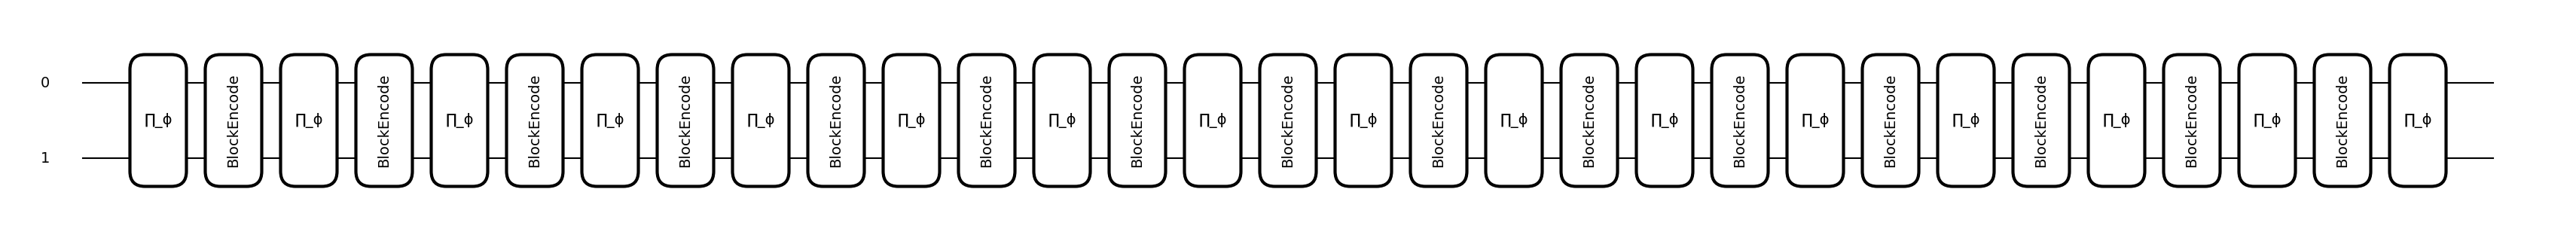

In [13]:
def qsvt_fn():
    qml.QSVT(block_encode, projectors)

qml.draw_mpl(qml.transforms.decompose(qsvt_fn))()
plt.show()

It is useful to visualize the high-level circuit structure behind QSVT. The circuit alternates between a block-encoding unitary, which stores the matrix $A$, and projector-controlled phase operators, which play the role of the signal-processing operators. Together, these operations transform the singular values of $A$ according to the chosen polynomial $p$.


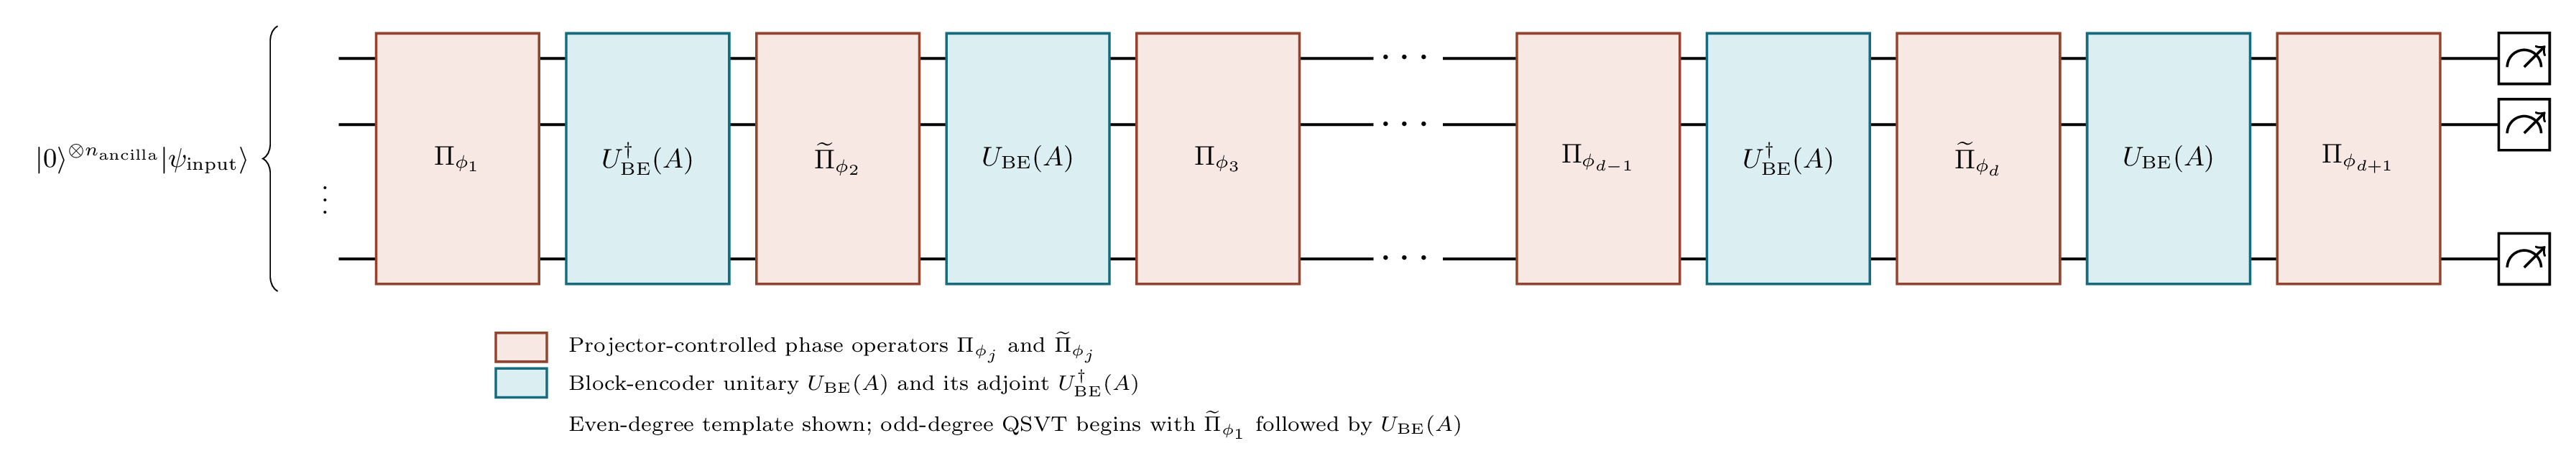
<p style="text-align: center; font-size: 0.9em;">
Figure: High-level QSVT circuit. The circuit alternates block-encoding unitaries with projector-controlled phase operators to implement a polynomial transformation $p^{(\mathrm{SV})}(A)$ of the singular values of $A$.
</p>

---
### QSVT as a Unifying Framework
 

QSVT is not just a technique for matrix inversion. Its strength comes from the flexibility of choosing the polynomial transformation. Many important quantum algorithms can be reinterpreted as polynomial transformations of spectral data, which is why QSVT is often labelled as ["A Grand Unification of Quantum Algorithms"](https://arxiv.org/abs/2105.02859).

In this view, Grover search, Hamiltonian simulation, phase estimation, and HHL-like matrix inversion are not isolated tricks, but different choices of block-encoding and polynomial transformation. It is important to note that QSVT does not literally rederive the standard specialized circuits, such as the usual Grover or HHL circuits, gate by gate. Rather, it provides a different route to solving similar tasks. For several examples of QSVT-based algorithms that perform tasks analogous to well-established quantum algorithms, see *A Grand Unification of Quantum Algorithms*.

At a high level, the connection can be summarized as follows:

| Task | QSVT viewpoint |
|---|---|
| Grover search | Amplify or distinguish amplitudes associated with marked states |
| Hamiltonian simulation | Approximate $\cos(Ht)$ and $\sin(Ht)$ to construct $e^{-iHt}$ |
| Phase estimation | Use threshold-like polynomial transformations to learn spectral information |
| Matrix inversion | Approximate $\frac{1}{x}$ on the relevant singular-value interval |

In short, QSVT gives a general framework for performing transformations on singular values. The main challenges are to identify the function of interest, find a suitable polynomial approximation, construct an appropriate block-encoding of the input matrix, and extract the desired information through suitable measurements.




---
### Comparison with Classical SVT

To the best of available evidence, the underlying idea of transforming singular values existed in classical numerical linear algebra long before QSVT, but it was usually studied through specific methods rather than as a single unified primitive called singular value transformation. For example, in [*A Singular Value Thresholding Algorithm for Matrix Completion*](https://arxiv.org/pdf/0810.3286), Cai, Candès, and Shen introduced an algorithm based on thresholding the singular values of a matrix. This is a singular-value transformation in spirit, but it is tied to a particular task: matrix completion.

After QSVT was formalized as a general quantum framework, related ideas were mirrored back into classical algorithms through the dequantization and quantum-inspired algorithms literature. A recent example is Tang and Bakshi's [*An Improved Classical Singular Value Transformation for Quantum Machine Learning*](https://arxiv.org/abs/2303.01492), which gives improved classical algorithms for approximating QSVT-like transformations in certain low-rank data-access models. Informally, given sampling/query access to a matrix $A$ and vector $b$, and a bounded polynomial $p$, Tang and Bakshi give a randomized classical algorithm that approximates a singular-value-transformed vector such as $p^{(\mathrm{SV})}(A)b$. The algorithm does not necessarily output the full vector explicitly. Instead, it provides query and sampling access to an approximate output vector, analogous to the kind of access produced by a quantum state.

---
### Conclusion 

In this tutorial, we began with quantum signal processing and motivated its connection to QSVT by noting that QSP implements polynomial transformations of a scalar signal. The polynomial must satisfy certain admissibility criteria, but many functions of interest can first be approximated by suitable polynomials and rescaled to fit these constraints. The basic building blocks of QSP are the signal operator and the signal-processing operator, which are applied in alternation.

QSVT generalizes this idea from scalar signals to matrices. Instead of transforming a scalar $a$, QSVT applies a polynomial transformation to the singular values of an input matrix $A$. The matrix must first be normalized and block-encoded into a larger unitary, and the resulting QSVT circuit follows a structure reminiscent of QSP: block-encoding unitaries are alternated with projector-controlled phase operators.

Seen as a general-purpose framework, QSVT provides a systematic way to implement a wide range of spectral transformations. This perspective connects many important quantum algorithms, including search, phase estimation, Hamiltonian simulation, and HHL-like matrix inversion. QSVT does not reproduce the exact standard circuits for these algorithms gate by gate; rather, it provides a different viewpoint and a more general tool for achieving related transformations.


---
### Appendix

---
### Appendix 1: Biography

- András Gilyén is a researcher in quantum algorithms and complexity theory. His work focuses on quantum linear algebra methods, including quantum singular value transformation, the block-encoding framework, optimization, and quantum walks. He received his Ph.D. from the University of Amsterdam in 2019, supervised by Ronald de Wolf and co-supervised by Harry Buhrman. His dissertation was [*Quantum Singular Value Transformation & Its Algorithmic Applications*](https://dare.uva.nl/id/20e9733e-6014-402d-afa9-20f3cc4a0568). He has held positions including an Institute for Quantum Information and Matter (IQIM) postdoctoral fellowship at Caltech and a Google Research Fellowship at the Simons Institute for the Theory of Computing. See also his [Simons Institute profile](https://simons.berkeley.edu/people/andras-gilyen) and [personal webpage](https://gilyen.hu/).

- Yuan Su is a researcher in theoretical quantum computing, with a focus on quantum simulation and quantum algorithms. He received his Ph.D. in Computer Science from the University of Maryland, where he was advised by Andrew Childs. His doctoral work, [*Algorithms for Quantum Simulation: Design, Analysis, Implementation, and Application*](https://obj.umiacs.umd.edu/su-dissertation/Su_umd_0117E_20745.pdf), received the 2020 Larry S. Davis Doctoral Dissertation Award. He has worked at institutions including Caltech, Google Quantum AI, Microsoft Quantum, and the AWS Center for Quantum Computing. He has also worked on later developments such as quantum eigenvalue processing. See his [personal website](https://yuansu.me/).

- Guang Hao Low is a quantum algorithms researcher known for major contributions to quantum signal processing, qubitization, Hamiltonian simulation, and quantum singular value transformation. Low received a Ph.D. in Physics from MIT in 2017 under Isaac Chuang. Low's dissertation was [*Quantum Signal Processing by Single-Qubit Dynamics*](https://dspace.mit.edu/handle/1721.1/115025), which developed ideas closely connected to the QSP framework that later fed into QSVT. See Low's [personal website](https://guanghaolow.github.io/).

- Nathan Wiebe is a researcher in quantum computing whose work spans quantum simulation, quantum machine learning, Hamiltonian learning, Bayesian phase estimation, and quantum algorithms for linear algebra. Wiebe received a Ph.D. in Physics from the University of Calgary in 2011, with Barry Sanders as supervisor and Peter Høyer as co-supervisor. Wiebe's dissertation was [*Quantum computer simulations of time-dependent Hamiltonians*](https://ucalgary.scholaris.ca/items/06c86f0d-1dc5-456f-9300-17eeb7836413). He later held positions at the Institute for Quantum Computing, Microsoft Research, the University of Washington, Pacific Northwest National Laboratory, and the University of Toronto. See this [University of Washington bio](https://www.ece.uw.edu/colloquia/nathan-wiebe/) and the [PNNL profile](https://www.pnnl.gov/people/nathan-wiebe).


---
### Appendix 2: References and Suggested Readings

1. Gilyén, András; Su, Yuan; Low, Guang Hao; & Wiebe, Nathan. (2019). *Quantum singular value transformation and beyond: exponential improvements for quantum matrix arithmetics*. Proceedings of the 51st Annual ACM SIGACT Symposium on Theory of Computing (STOC 2019), 193-204. DOI: [10.1145/3313276.3316366](https://doi.org/10.1145/3313276.3316366). [[arXiv](https://arxiv.org/abs/1806.01838)].

2. Low, Guang Hao; & Chuang, Isaac L. (2017). *Optimal Hamiltonian Simulation by Quantum Signal Processing*. Physical Review Letters, 118, 010501. DOI: [10.1103/PhysRevLett.118.010501](https://doi.org/10.1103/PhysRevLett.118.010501). [[arXiv](https://arxiv.org/abs/1606.02685)].

3. Martyn, John M.; Rossi, Zane M.; Tan, Andrew K.; & Chuang, Isaac L. (2021). *A Grand Unification of Quantum Algorithms*. PRX Quantum, 2, 040203. DOI: [10.1103/PRXQuantum.2.040203](https://doi.org/10.1103/PRXQuantum.2.040203). [[arXiv](https://arxiv.org/abs/2105.02859)].

4. Motlagh, Danial; & Wiebe, Nathan. (2024). *Generalized Quantum Signal Processing*. PRX Quantum, 5, 020368. DOI: [10.1103/PRXQuantum.5.020368](https://doi.org/10.1103/PRXQuantum.5.020368). [[arXiv](https://arxiv.org/abs/2308.01501)].


5. Bakshi, Ainesh; & Tang, Ewin. (2024). *An Improved Classical Singular Value Transformation for Quantum Machine Learning*. Proceedings of the 2024 Annual ACM-SIAM Symposium on Discrete Algorithms (SODA 2024), 2398-2453. DOI: [10.1137/1.9781611977912.86](https://doi.org/10.1137/1.9781611977912.86). [[arXiv](https://arxiv.org/abs/2303.01492)].


6. Low, Guang Hao; & Su, Yuan. (2026). *Quantum eigenvalue processing*. SIAM Journal on Computing, 55(1), 135-215. DOI: [10.1137/24M1689363](https://doi.org/10.1137/24M1689363). [[arXiv](https://arxiv.org/abs/2401.06240)].

7. Arrazola, Juan Miguel. (2023). *Intro to QSVT*. PennyLane Demos. Published May 22, 2023. Available at: https://pennylane.ai/qml/demos/tutorial_intro_qsvt.

8. Soni, Jay; & Smalley, Jarrett. (2023). *QSVT in Practice*. PennyLane Demos. Published August 21, 2023. Available at: https://pennylane.ai/qml/demos/tutorial_apply_qsvt.

9. Soni, Jay. (2022). *Function Fitting using Quantum Signal Processing*. PennyLane Demos. Published May 23, 2022. Available at: https://pennylane.ai/qml/demos/function_fitting_qsp.

10. Soni, Jay; Guala, Diego; & Jahangiri, Soran. (2023). *Block encoding with matrix access oracles*. PennyLane Demos. Published November 27, 2023. Available at: https://pennylane.ai/qml/demos/tutorial_block_encoding.

11. Arrazola, Juan Miguel; Guala, Diego; & Soni, Jay. (2023). *Linear combination of unitaries and block encodings*. PennyLane Demos. Published October 24, 2023. Available at: https://pennylane.ai/qml/demos/tutorial_lcu_blockencoding.
